## Importing Dataset2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [3]:
# Read the file
with open('dataset_position_scenario_max_prof_50_dist_max.txt', 'r') as f:
    lines = f.readlines()

# Split each line into dictionary entries
data = []
for line in lines:
    parts = line.strip().split(';')
    row = {'timestamp': parts[0], 'index': parts[1]}
    for item in parts[2:]:
        if '=' in item:
            k, v = item.split('=')
            row[k.strip()] = v.strip()
    data.append(row)

# Convert to DataFrame
df = pd.DataFrame(data)
df.head(100)



,timestamp,index,H,T,Hs,sp,sf,rx_timestamp,rssi,snr,sfrx,sftx,tx_trials,tx_power,tx_time_on_air,tx_counter,tx_frequency,prof,dist,obst
0,2024-07-06 10:50:05.719357,85,76,27,52.58283,2,7,7865369,-122,-5.0,7,0,0,14,0,0,0,50,0,0
1,2024-07-06 10:50:28.773681,86,76,27,52.58283,2,12,30741770,-123,-5.0,12,0,0,14,0,0,0,50,0,0
2,2024-07-06 10:50:47.783414,87,76,27,52.58283,20,7,50096495,-110,5.0,7,0,0,14,0,0,0,50,0,0
3,2024-07-06 10:51:11.222562,88,76,27,52.58283,20,12,73136508,-109,5.0,12,0,0,14,0,0,0,50,0,0
4,2024-07-06 10:55:48.319521,101,76,27,52.76096,2,7,350004492,-85,6.0,7,0,0,14,0,0,0,50,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2024-07-06 12:38:51.377288,387,89,29,42.75027,20,7,2238400740,-71,6.0,7,0,0,14,0,0,0,50,0,0
96,2024-07-06 12:39:14.272771,388,89,29,42.75027,20,12,2261443699,-72,6.0,12,0,0,14,0,0,0,50,0,0
97,2024-07-06 12:39:35.229343,389,72,29,42.03776,2,7,2281700643,-92,6.0,7,0,0,14,0,0,0,50,0,0
98,2024-07-06 12:39:58.686254,390,72,29,42.03776,2,12,2304741601,-85,8.0,12,0,0,14,0,0,0,50,0,0


## Data Preprocessing

In [4]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

In [5]:
for col in df.columns:
    if col != 'timestamp':
        df[col] = pd.to_numeric(df[col], errors='coerce')


In [6]:
df =df[['H', 'T', 'Hs', 'sp', 'sf','rssi','snr','sfrx']].copy()

## Introduction missing values

In [7]:
rng = np.random.RandomState(42)
data_missing = df.copy()
mask = rng.rand(*df.shape) < 0.2
data_missing[mask] = np.nan

## Interative-SVD Model

In [8]:
def svd_pca_impute(df, variance_threshold=0.85, max_iter=20, tol=1e-4):
    X = df.to_numpy()
    missing_mask = np.isnan(X)
    
    # Initial imputation with column means
    X_filled = X.copy()
    col_means = np.nanmean(X_filled, axis=0)
    inds = np.where(np.isnan(X_filled))
    X_filled[inds] = np.take(col_means, inds[1])

    # Standardize data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_filled)
    
    # Fit SVD once to find k components covering variance_threshold
    svd_full = TruncatedSVD(n_components=min(X_scaled.shape)-1, random_state=42)
    svd_full.fit(X_scaled)
    explained_var = np.cumsum(svd_full.explained_variance_ratio_)
    k = np.searchsorted(explained_var, variance_threshold) + 1
    print(f"Chosen components k={k} to explain {variance_threshold*100}% variance")

    for iteration in range(max_iter):
        X_old = X_scaled.copy()

        # Fit SVD with k components
        svd = TruncatedSVD(n_components=k, random_state=42)
        X_svd = svd.fit_transform(X_scaled)
        V_k = svd.components_

        # Reconstruct data from top-k components
        X_reconstructed = X_svd @ V_k

        # Update only missing entries
        X_scaled[missing_mask] = X_reconstructed[missing_mask]

        # Convergence check
        diff = np.linalg.norm(X_scaled - X_old) / np.linalg.norm(X_old)
        print(f"Iteration {iteration+1}, relative change: {diff:.6f}")
        if diff < tol:
            print("Converged.")
            break

    # Inverse transform to original scale
    X_imputed = scaler.inverse_transform(X_scaled)
    return pd.DataFrame(X_imputed, columns=df.columns), missing_mask

def evaluate_imputation(original_df, imputed_df, missing_mask):
    scaler = MinMaxScaler()
    original_scaled = scaler.fit_transform(original_df)
    imputed_scaled = scaler.transform(imputed_df)

    for i, col in enumerate(original_df.columns):
        true_vals = original_scaled[:, i]
        pred_vals = imputed_scaled[:, i]
        mask = missing_mask[:, i]

        print(f"\n{col} (Metrics on Normalized [0,1] Scale):")
        print(f"  [All_R2] {r2_score(true_vals, pred_vals):.4f}")
        print(f"  [All_MSE] {mean_squared_error(true_vals, pred_vals):.4f}")
        print(f"  [All_MAE] {mean_absolute_error(true_vals, pred_vals):.4f}")

        if mask.any():
            print(f"  [Missing_R2] {r2_score(true_vals[mask], pred_vals[mask]):.4f}")
            print(f"  [Missing_MSE] {mean_squared_error(true_vals[mask], pred_vals[mask]):.4f}")
            print(f"  [Missing_MAE] {mean_absolute_error(true_vals[mask], pred_vals[mask]):.4f}")
        else:
            print("  [Missing_R2] No missing values for this feature.")
            print("  [Missing_MSE] No missing values for this feature.")
            print("  [Missing_MAE] No missing values for this feature.")
df_imputed, missing_mask = svd_pca_impute(data_missing)

print("\nOriginal Data:")
print(df.head(20))

print("\nData with Missing Values:")
print(data_missing.head(20))

print("\nImputed Data:")
print(df_imputed.head(20))

evaluate_imputation(df, df_imputed, missing_mask)


Chosen components k=5 to explain 85.0% variance
Iteration 1, relative change: 0.185270
Iteration 2, relative change: 0.099872
Iteration 3, relative change: 0.068849
Iteration 4, relative change: 0.056753
Iteration 5, relative change: 0.046873
Iteration 6, relative change: 0.037626
Iteration 7, relative change: 0.030268
Iteration 8, relative change: 0.024872
Iteration 9, relative change: 0.020986
Iteration 10, relative change: 0.018155
Iteration 11, relative change: 0.016048
Iteration 12, relative change: 0.014443
Iteration 13, relative change: 0.013191
Iteration 14, relative change: 0.012194
Iteration 15, relative change: 0.011384
Iteration 16, relative change: 0.010713
Iteration 17, relative change: 0.010148
Iteration 18, relative change: 0.009666
Iteration 19, relative change: 0.009249
Iteration 20, relative change: 0.008884

Original Data:
                             H   T        Hs  sp  sf  rssi   snr  sfrx
timestamp                                                             
202

## RNN-LSTM Model

In [9]:
# --- 1. Load and select relevant columns ---
features = ['H', 'T', 'Hs', 'sp', 'sf','rssi','snr','sfrx']
df = data_missing[features].copy()

# --- 2. Preprocessing and scaling ---
df_filled = df.fillna(method="ffill").fillna(method="bfill")
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_filled)
scaled_df = pd.DataFrame(scaled_data, columns=features, index=df.index)

# --- 3. Build training sequences ---
window_size = 10
X_train, y_train = [], []
for i in range(window_size, len(scaled_df)):
    window = scaled_data[i - window_size:i]
    target = scaled_data[i]
    if not np.isnan(df.iloc[i].values).any() and not np.isnan(window).any():
        X_train.append(window)
        y_train.append(target)
X_train, y_train = np.array(X_train), np.array(y_train)

# --- 4. Build and train LSTM model ---
model = Sequential([
    LSTM(64, activation='relu', input_shape=(window_size, len(features))),
    Dense(len(features))
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=30, verbose=1)

# --- 5. Impute missing values using LSTM predictions ---
imputed_scaled_data = scaled_data.copy()
for i in range(window_size, len(scaled_data)):
    if np.any(np.isnan(df.iloc[i].values)):
        window = imputed_scaled_data[i - window_size:i]
        if np.isnan(window).any():
            continue
        input_seq = window.reshape(1, window_size, -1)
        pred = model.predict(input_seq, verbose=0)[0]
        nan_mask = df.iloc[i].isna().values
        imputed_scaled_data[i][nan_mask] = pred[nan_mask]

# --- 6. Inverse scaling back to original units ---
imputed_df = pd.DataFrame(scaler.inverse_transform(imputed_scaled_data),
                          columns=features, index=df.index)

# --- 7. Combine with original data for comparison ---
comparison = df.copy()
for col in features:
    comparison[col + '_imputed'] = imputed_df[col]

print("\n--- Rows with original missing values ---")
print(comparison[df.isna().any(axis=1)].head(10))

# --- 8. Evaluation Metrics (MAE, MSE, R²) on Scaled Data ---
# Evaluate scaled_df (true, filled) vs imputed_scaled_data (pred)
mae_all, mse_all, r2_all = {}, {}, {}
mae_missing, mse_missing, r2_missing = {}, {}, {}

for col in features:
    true_all = scaled_df[col]
    pred_all = imputed_scaled_data[:, scaled_df.columns.get_loc(col)]
    
    mae_all[col] = mean_absolute_error(true_all, pred_all)
    mse_all[col] = mean_squared_error(true_all, pred_all)
    r2_all[col] = r2_score(true_all, pred_all)
    
    mask_missing = df[col].isna()
    if mask_missing.any():
        true_missing = scaled_df.loc[mask_missing, col]
        pred_missing = pd.Series(imputed_scaled_data[mask_missing.values, scaled_df.columns.get_loc(col)], index=true_missing.index)
        mae_missing[col] = mean_absolute_error(true_missing, pred_missing)
        mse_missing[col] = mean_squared_error(true_missing, pred_missing)
        r2_missing[col] = r2_score(true_missing, pred_missing)
    else:
        mae_missing[col], mse_missing[col], r2_missing[col] = None, None, None

# --- 9. Print Evaluation Results ---
print("\n--- Evaluation Metrics (All Data, Scaled) ---")
for col in features:
    print(f"\nFeature: {col}")
    print(f"MAE (All, Scaled): {mae_all[col]:.4f}")
    print(f"MSE (All, Scaled): {mse_all[col]:.4f}")
    print(f"R² (All, Scaled): {r2_all[col]:.4f}")

print("\n--- Evaluation Metrics (Only Missing Data, Scaled) ---")
for col in features:
    if mae_missing[col] is not None:
        print(f"\nFeature: {col}")
        print(f"MAE (Missing, Scaled): {mae_missing[col]:.4f}")
        print(f"MSE (Missing, Scaled): {mse_missing[col]:.4f}")
        print(f"R² (Missing, Scaled): {r2_missing[col]:.4f}")
    else:
        print(f"\nFeature: {col} - No missing values")



Epoch 1/30


/tmp/ipykernel_289640/3278303544.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filled = df.fillna(method="ffill").fillna(method="bfill")
2025-05-30 09:42:02.014913: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/student24/myenv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 735ms/step - loss: 0.4353
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.4161
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.3976
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.3799
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.3627
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.3459
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.3295
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.3134
Epoch 9/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.2975
Epoch 10/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.2816
Epoch 11/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.2657
Epoch 12/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.2499
Epoch 13/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.2341
Epoch 14/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.2184
Epoch 15/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.2029
Epoch 16/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms

In [2]:
import pandas as pd

# Data dictionary with performance metrics
data = {
    "Feature": ["H", "H", "T", "T", "Hs", "Hs", "sp", "sp", "sf", "sf",
                "rssi", "rssi", "snr", "snr", "sfrx", "sfrx"],
    "Model": ["LSTM", "SVD"] * 8,
    "All R²": [0.7796, 0.3214, 0.7704, 0.5616, 0.7212, 0.6878, 0.7423, 0.8155,
               0.7817, 0.9699, 0.8843, 0.8997, 0.7807, 0.8581, 0.8587, 0.9697],
    "All MSE": [0.0104, 0.0320, 0.0153, 0.0291, 0.0247, 0.0288, 0.0427, 0.0274,
                0.0546, 0.0075, 0.0064, 0.0058, 0.0138, 0.0076, 0.0347, 0.0076],
    "All MAE": [0.0390, 0.0714, 0.0465, 0.0596, 0.0559, 0.0639, 0.0756, 0.0572,
                0.0999, 0.0210, 0.0219, 0.0252, 0.0494, 0.0350, 0.0721, 0.0207],
    "Missing R²": [-0.0542, -2.2865, 0.1270, -0.6910, 0.1104, 0.0810, -0.0804, -0.1500,
                   -0.0684, 0.8502, 0.3229, 0.5173, 0.3231, 0.3987, -0.1890, 0.8205],
    "Missing MSE": [0.0415, 0.1275, 0.0699, 0.1330, 0.1020, 0.1192, 0.2237, 0.1437,
                    0.2666, 0.0367, 0.0346, 0.0312, 0.0558, 0.0308, 0.2015, 0.0441],
    "Missing MAE": [0.1552, 0.2844, 0.2125, 0.2727, 0.2309, 0.2642, 0.3967, 0.3000,
                    0.4881, 0.1025, 0.1175, 0.1352, 0.2003, 0.1419, 0.4187, 0.1204]
}

# Creating the DataFrame with the correct column order
columns = ['Feature', 'Model', 'All R²', 'All MSE', 'All MAE', 
           'Missing R²', 'Missing MSE', 'Missing MAE']
df = pd.DataFrame(data, columns=columns)




       Final_Grade
Model             
SVD       0.741436
LSTM      0.570953


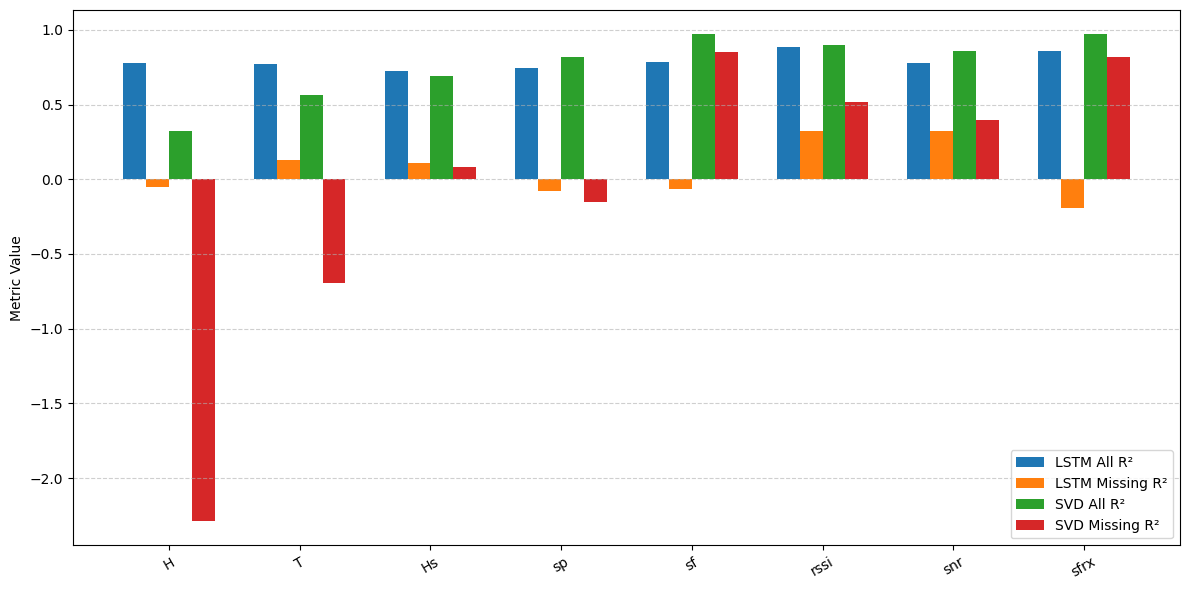

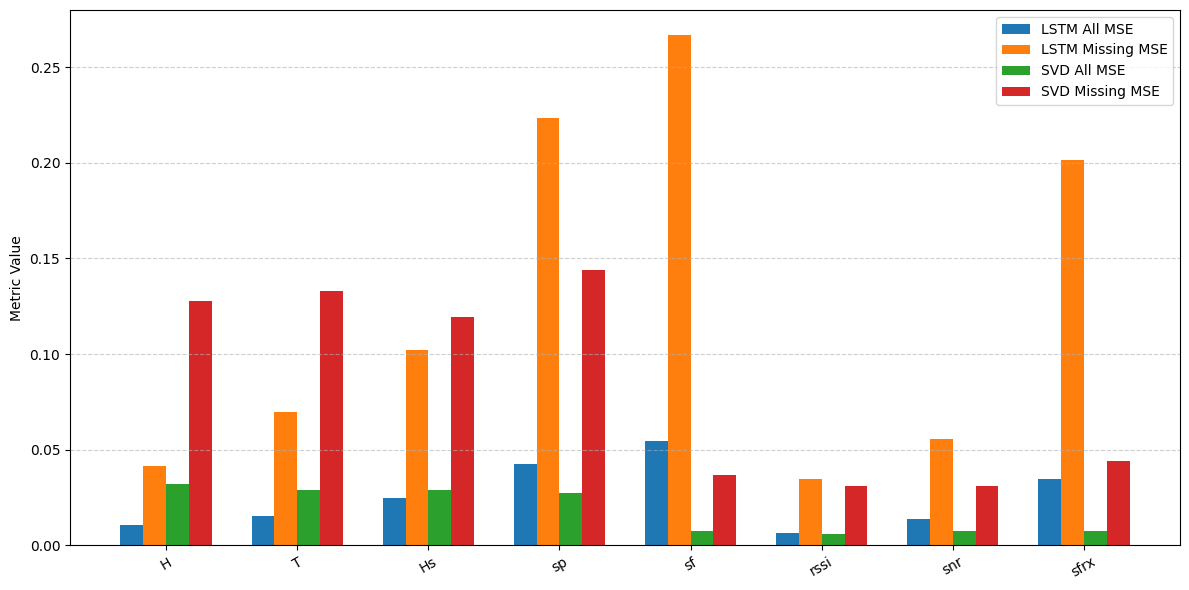

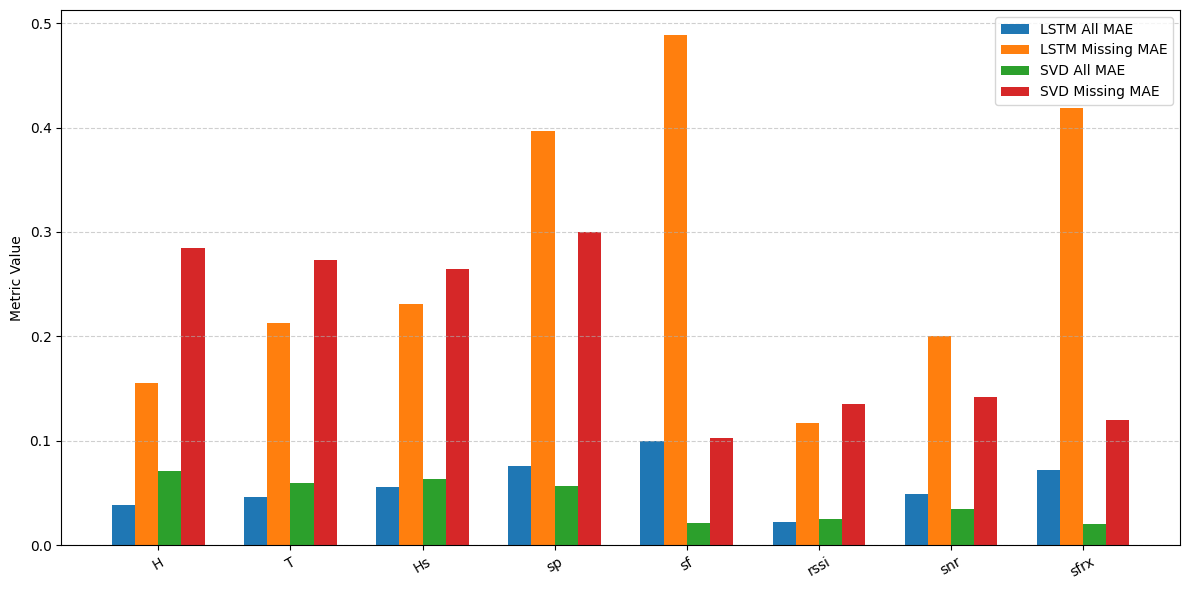

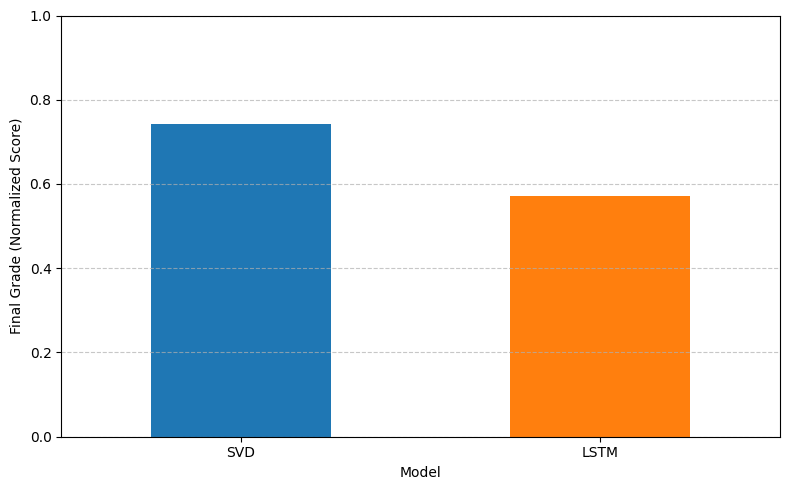

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



# Include R² in normalization (True = higher is better, False = lower is better)
metrics = {
    'All R²': True,
    'All MSE': False,
    'All MAE': False,
    'Missing R²': True,
    'Missing MSE': False,
    'Missing MAE': False
}

# Normalize selected metrics
for metric, higher_is_better in metrics.items():
    col = df[metric]
    min_val, max_val = col.min(), col.max()
    if max_val - min_val == 0:
        df[metric + '_norm'] = 1.0
    else:
        if higher_is_better:
            df[metric + '_norm'] = (col - min_val) / (max_val - min_val)
        else:
            df[metric + '_norm'] = (max_val - col) / (max_val - min_val)

# --- Compute final grade (excluding R² metrics) ---
exclude_metrics = ['All R²', 'Missing R²']
norm_cols_for_grade = [m + '_norm' for m in metrics.keys() if m not in exclude_metrics]

model_scores = df.groupby('Model')[norm_cols_for_grade].mean()
model_scores['Final_Grade'] = model_scores.mean(axis=1)
model_scores = model_scores.sort_values('Final_Grade', ascending=False)

print(model_scores[['Final_Grade']])

# --- Plot comparison of each model's metrics ---
features = df['Feature'].unique()
models = df['Model'].unique()
x = np.arange(len(features))
width = 0.35

# Show R², MSE, and MAE for both All and Missing
metric_pairs = [('All R²', 'Missing R²'), ('All MSE', 'Missing MSE'), ('All MAE', 'Missing MAE')]

for metric1, metric2 in metric_pairs:
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, model in enumerate(models):
        vals1 = df[df['Model'] == model][metric1].values
        vals2 = df[df['Model'] == model][metric2].values
        pos = x + (i - 0.5) * width
        ax.bar(pos - width/4, vals1, width/2, label=f'{model} {metric1}')
        ax.bar(pos + width/4, vals2, width/2, label=f'{model} {metric2}')
    ax.set_xticks(x)
    ax.set_xticklabels(features, rotation=30)
    ax.set_ylabel('Metric Value')
    ax.legend()
    ax.grid(axis='y', alpha=0.6, linestyle='--')
    plt.tight_layout()
#     plt.title(f'Comparison of {metric1} and {metric2}')
    plt.show()

# Final Grade Plot
plt.figure(figsize=(8, 5))
model_scores['Final_Grade'].plot(kind='bar', color=['tab:blue', 'tab:orange'])
plt.ylabel('Final Grade (Normalized Score)')
plt.ylim(0, 1)
plt.xticks(rotation=0)
# plt.title("Model Comparison Based on Normalized Metrics (Excluding R²)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


       Final_Grade
Model             
SVD       0.741436
LSTM      0.570953


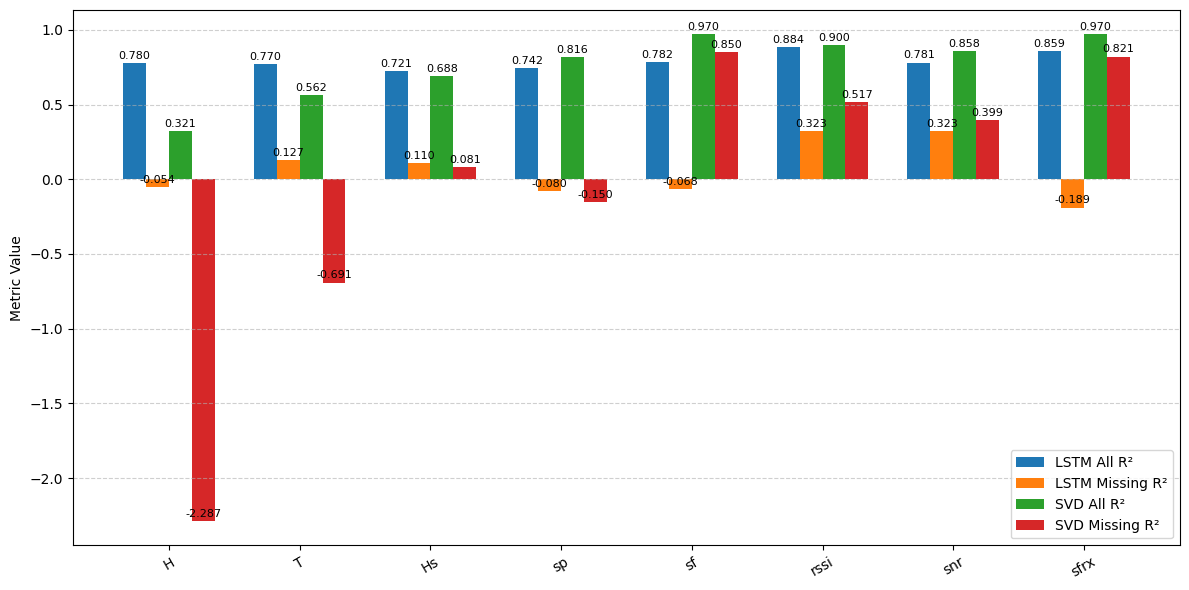

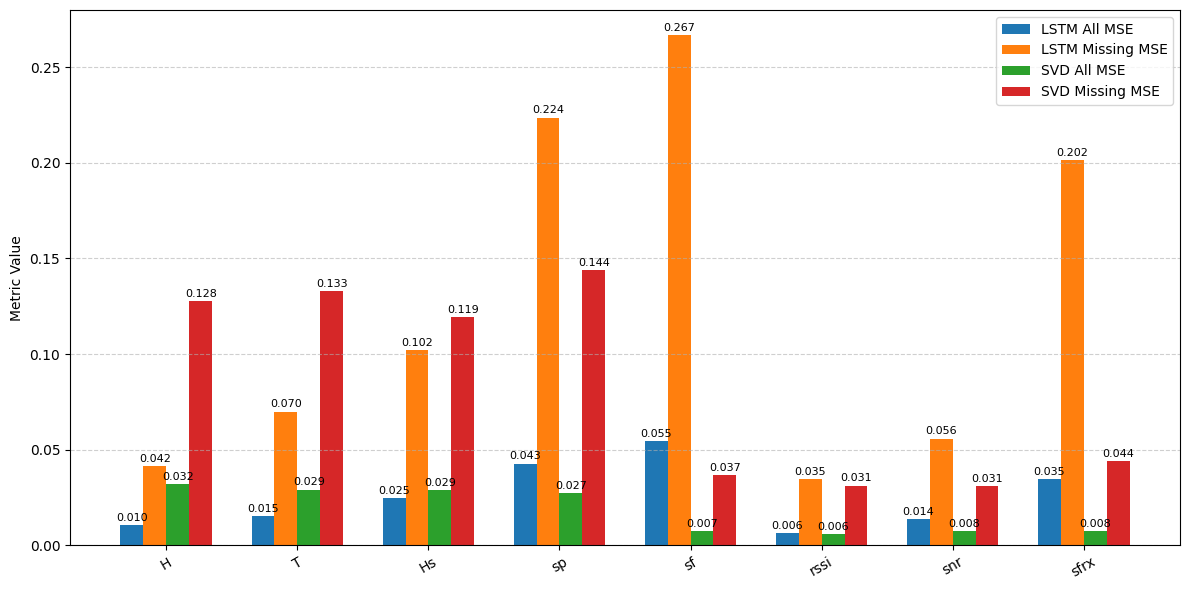

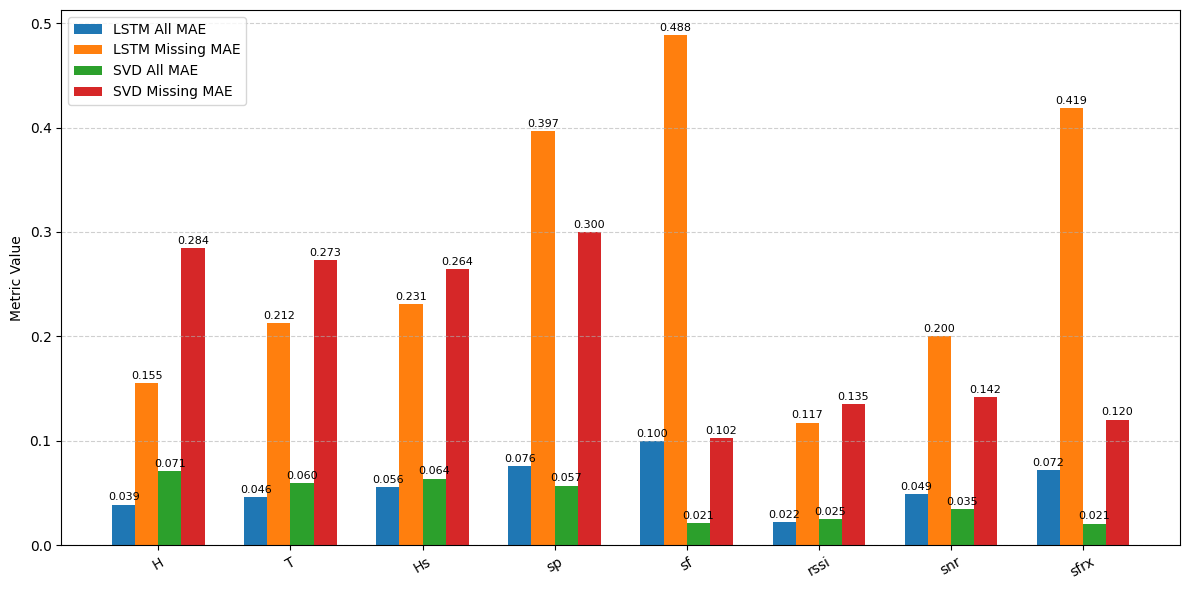

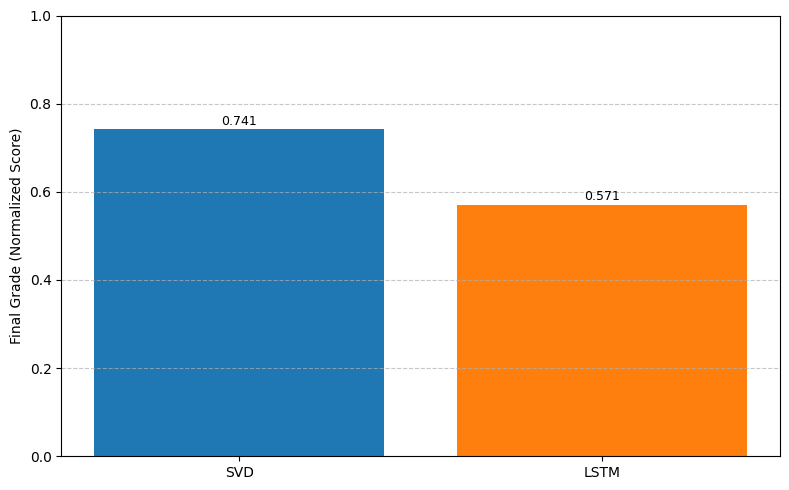

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Include R² in normalization (True = higher is better, False = lower is better)
metrics = {
    'All R²': True,
    'All MSE': False,
    'All MAE': False,
    'Missing R²': True,
    'Missing MSE': False,
    'Missing MAE': False
}

# Normalize selected metrics
for metric, higher_is_better in metrics.items():
    col = df[metric]
    min_val, max_val = col.min(), col.max()
    if max_val - min_val == 0:
        df[metric + '_norm'] = 1.0
    else:
        if higher_is_better:
            df[metric + '_norm'] = (col - min_val) / (max_val - min_val)
        else:
            df[metric + '_norm'] = (max_val - col) / (max_val - min_val)

# --- Compute final grade (excluding R² metrics) ---
exclude_metrics = ['All R²', 'Missing R²']
norm_cols_for_grade = [m + '_norm' for m in metrics.keys() if m not in exclude_metrics]

model_scores = df.groupby('Model')[norm_cols_for_grade].mean()
model_scores['Final_Grade'] = model_scores.mean(axis=1)
model_scores = model_scores.sort_values('Final_Grade', ascending=False)

print(model_scores[['Final_Grade']])

# --- Plot comparison of each model's metrics ---
features = df['Feature'].unique()
models = df['Model'].unique()
x = np.arange(len(features))
width = 0.35

metric_pairs = [('All R²', 'Missing R²'), ('All MSE', 'Missing MSE'), ('All MAE', 'Missing MAE')]

for metric1, metric2 in metric_pairs:
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, model in enumerate(models):
        vals1 = df[df['Model'] == model][metric1].values
        vals2 = df[df['Model'] == model][metric2].values
        pos = x + (i - 0.5) * width
        bars1 = ax.bar(pos - width/4, vals1, width/2, label=f'{model} {metric1}')
        bars2 = ax.bar(pos + width/4, vals2, width/2, label=f'{model} {metric2}')
        
        # Add bar labels
        for bar in bars1:
            height = bar.get_height()
            ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)
        for bar in bars2:
            height = bar.get_height()
            ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(features, rotation=30)
    ax.set_ylabel('Metric Value')
    ax.legend()
    ax.grid(axis='y', alpha=0.6, linestyle='--')
    plt.tight_layout()
#     plt.title(f'Comparison of {metric1} and {metric2}')
    plt.show()

# Final Grade Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(model_scores.index, model_scores['Final_Grade'], color=['tab:blue', 'tab:orange'])

# Add bar labels
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.ylabel('Final Grade (Normalized Score)')
plt.ylim(0, 1)
plt.xticks(rotation=0)
# plt.title("Model Comparison Based on Normalized Metrics (Excluding R²)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
